# Task 7 — Comparison Between Rolling OOS and Full-Sample IS Results

## Purpose

Task 7 compares the final results from:

- **Task 5:** Rolling Walk-Forward Out-of-Sample Optimization
- **Task 6:** Full-Sample In-Sample Optimization

The purpose of this comparison is to evaluate how the more realistic rolling out-of-sample procedure differs from a hindsight-optimized full-sample benchmark.

Task 5 repeatedly selects parameters using only historical information available before each out-of-sample quarter and therefore provides the more realistic estimate of historical strategy performance under a deployable walk-forward framework.

Task 6 instead uses the complete historical sample to identify one fixed globally optimal parameter pair. Its results therefore represent an in-sample benchmark rather than an unbiased estimate of future performance.

Task 7 focuses on two questions:

1. How do the rolling OOS and full-sample IS results differ in profitability, drawdown, and risk-adjusted performance?

2. Does the rolling strategy retain a favorable trade-level payoff structure when evaluated out of sample?

The comparison is designed to assess historical strategy robustness without treating the full-sample optimum as a guaranteed upper bound on the dynamically optimized walk-forward strategy.

In [1]:
# 0. Imports and Configuration

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    160
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

DATA_DIR = Path("data")
CLEAN_DIR = DATA_DIR / "clean"


# ------------------------------------------------------------
# Common strategy assumptions
# ------------------------------------------------------------

INITIAL_EQUITY = 100_000.0
PV = 50.0
SLPG = 35.5


print(
    "TASK 7 — COMPARISON ANALYSIS CONFIGURATION"
)

print(
    "=" * 60
)

print(
    f"Initial equity:       ${INITIAL_EQUITY:,.2f}"
)

print(
    f"Point value:          ${PV:,.2f}"
)

print(
    f"Round-turn slippage:  ${SLPG:,.2f}"
)

print(
    "\nTask 5: Rolling Walk-Forward OOS"
)

print(
    "Task 6: Full-Sample IS Benchmark"
)

print(
    "\nNo new parameter optimization is performed in Task 7."
)

TASK 7 — COMPARISON ANALYSIS CONFIGURATION
Initial equity:       $100,000.00
Point value:          $50.00
Round-turn slippage:  $35.50

Task 5: Rolling Walk-Forward OOS
Task 6: Full-Sample IS Benchmark

No new parameter optimization is performed in Task 7.


## 1. Final Inputs from Tasks 5 and 6

Task 7 uses the finalized outputs from Tasks 5 and 6 as its comparison inputs.
No parameters are re-estimated and no strategy results are re-optimized in this
section.

The two procedures are first recorded separately before constructing
apples-to-apples portfolio-, trade-, and parameter-level comparisons.

### 1.1 Task 5 — Rolling Walk-Forward OOS Results

Task 5 provides the rolling out-of-sample benchmark. Parameters are selected
separately for each quarter using the preceding four-year in-sample window,
and performance is then evaluated over the following three-month OOS period.

The finalized Task 5 results below use the IS-conditioned OOS implementation
and the same strategy rules, point value, and transaction-cost assumptions used
throughout the project.

In [2]:
task5_portfolio = {
    "Procedure": "Rolling Walk-Forward OOS",
    "Start Date": pd.Timestamp("1986-07-01 09:35:00"),
    "End Date": pd.Timestamp("2026-03-31 13:15:00"),
    "Starting Equity": 100_000.0,
    "Ending Equity": 372_260.74,
    "Net Profit": 272_260.74,
    "Total Return": 2.7226074,
    "CAGR": 0.0336,
    "Maximum Drawdown ($)": -8_771.15,
    "Maximum Drawdown (%)": -0.0679,
    "Daily Sharpe Ratio": 1.3450,
    "Calmar Ratio": 0.4953,
    "OOS Quarters": 159
}


task5_trades = {
    "Completed Trades": 2_101,
    "Winning Trades": 917,
    "Losing Trades": 1_184,
    "Win Rate": 0.4365,
    "Profit Factor": 1.9740,
    "Expectancy per Trade": 117.86,
    "Median Trade P&L": -60.56,
    "Average Winner": 547.28,
    "Average Loser": -214.73,
    "Winner / Loser Payoff Ratio": 547.28 / 214.73,
    "Average Holding Bars": 29.6721,
    "Median Holding Bars": 9
}


task5_parameters = {
    "Rolling Windows": 159,
    "ChnLen Median": 1_110.0,
    "ChnLen Mean": 2_516.5409,
    "ChnLen Minimum": 500,
    "ChnLen Maximum": 9_740,
    "StpPct Median": 0.006,
    "StpPct Mean": 0.0109,
    "StpPct Minimum": 0.005,
    "StpPct Maximum": 0.066
}


# ------------------------------------------------------------
# Display finalized Task 5 inputs
# ------------------------------------------------------------

task5_input_summary = pd.DataFrame(
    {
        "Metric": [
            "OOS Start Date",
            "OOS End Date",
            "OOS Quarters",
            "Starting Equity",
            "Ending Equity",
            "Net Profit",
            "Total Return",
            "CAGR",
            "Maximum Drawdown ($)",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio",
            "Completed Trades",
            "Win Rate",
            "Profit Factor",
            "Expectancy per Trade"
        ],

        "Value": [
            task5_portfolio["Start Date"],
            task5_portfolio["End Date"],
            f'{task5_portfolio["OOS Quarters"]:,}',
            f'${task5_portfolio["Starting Equity"]:,.2f}',
            f'${task5_portfolio["Ending Equity"]:,.2f}',
            f'${task5_portfolio["Net Profit"]:,.2f}',
            f'{task5_portfolio["Total Return"]:.2%}',
            f'{task5_portfolio["CAGR"]:.2%}',
            f'${task5_portfolio["Maximum Drawdown ($)"]:,.2f}',
            f'{task5_portfolio["Maximum Drawdown (%)"]:.2%}',
            f'{task5_portfolio["Daily Sharpe Ratio"]:.4f}',
            f'{task5_portfolio["Calmar Ratio"]:.4f}',
            f'{task5_trades["Completed Trades"]:,}',
            f'{task5_trades["Win Rate"]:.2%}',
            f'{task5_trades["Profit Factor"]:.4f}',
            f'${task5_trades["Expectancy per Trade"]:,.2f}'
        ]
    }
)


print(
    "TASK 5 — FINAL ROLLING OOS INPUTS"
)

print(
    "=" * 60
)

display(
    task5_input_summary
)

TASK 5 — FINAL ROLLING OOS INPUTS


,Metric,Value
0,OOS Start Date,1986-07-01 09:35:00
1,OOS End Date,2026-03-31 13:15:00
2,OOS Quarters,159
3,Starting Equity,"$100,000.00"
4,Ending Equity,"$372,260.74"
5,Net Profit,"$272,260.74"
6,Total Return,272.26%
7,CAGR,3.36%
8,Maximum Drawdown ($),"$-8,771.15"
9,Maximum Drawdown (%),-6.79%


### 1.2 Task 6 — Full-Sample IS Results

Task 6 provides the full-sample in-sample benchmark. The complete Soybean
history is treated as a single in-sample period, and all 91,296 prescribed
parameter combinations are evaluated to identify one globally optimal fixed
parameter pair.

The resulting performance is a hindsight-optimized benchmark rather than an
out-of-sample estimate. It is recorded here using the same portfolio- and
trade-level metric definitions used for the finalized Task 5 results.

In [3]:
task6_portfolio = {
    "Procedure": "Full-Sample IS",
    "Start Date": pd.Timestamp("1982-10-29 12:05:00"),
    "End Date": pd.Timestamp("2026-04-10 13:15:00"),
    "Starting Equity": 100_000.0,
    "Ending Equity": 266_511.65,
    "Net Profit": 166_511.65,
    "Total Return": 1.6651165,
    "CAGR": 0.0228,
    "Maximum Drawdown ($)": -4_412.49,
    "Maximum Drawdown (%)": -0.0368,
    "Daily Sharpe Ratio": 1.1910,
    "Calmar Ratio": 0.6205
}


task6_trades = {
    "Completed Trades": 1_069,
    "Winning Trades": 462,
    "Losing Trades": 607,
    "Win Rate": 0.4322,
    "Profit Factor": 2.1161,
    "Expectancy per Trade": 155.76,
    "Median Trade P&L": -73.30,
    "Average Winner": 683.35,
    "Average Loser": -245.79,
    "Winner / Loser Payoff Ratio": 2.7802,
    "Average Holding Bars": 35.45,
    "Median Holding Bars": 22
}


task6_parameters = {
    "Optimal ChnLen": 3_810,
    "Optimal StpPct": 0.009,
    "Parameter Combinations": 91_296,
    "Optimization Objective": 37.736458
}


# ------------------------------------------------------------
# Display finalized Task 6 inputs
# ------------------------------------------------------------

task6_input_summary = pd.DataFrame(
    {
        "Metric": [
            "IS Start Date",
            "IS End Date",
            "Optimal ChnLen",
            "Optimal StpPct",
            "Parameter Combinations",
            "Starting Equity",
            "Ending Equity",
            "Net Profit",
            "Total Return",
            "CAGR",
            "Maximum Drawdown ($)",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio",
            "Completed Trades",
            "Win Rate",
            "Profit Factor",
            "Expectancy per Trade"
        ],

        "Value": [
            task6_portfolio["Start Date"],
            task6_portfolio["End Date"],
            f'{task6_parameters["Optimal ChnLen"]:,}',
            (
                f'{task6_parameters["Optimal StpPct"]:.3f} '
                f'({task6_parameters["Optimal StpPct"]:.1%})'
            ),
            f'{task6_parameters["Parameter Combinations"]:,}',
            f'${task6_portfolio["Starting Equity"]:,.2f}',
            f'${task6_portfolio["Ending Equity"]:,.2f}',
            f'${task6_portfolio["Net Profit"]:,.2f}',
            f'{task6_portfolio["Total Return"]:.2%}',
            f'{task6_portfolio["CAGR"]:.2%}',
            f'${task6_portfolio["Maximum Drawdown ($)"]:,.2f}',
            f'{task6_portfolio["Maximum Drawdown (%)"]:.2%}',
            f'{task6_portfolio["Daily Sharpe Ratio"]:.4f}',
            f'{task6_portfolio["Calmar Ratio"]:.4f}',
            f'{task6_trades["Completed Trades"]:,}',
            f'{task6_trades["Win Rate"]:.2%}',
            f'{task6_trades["Profit Factor"]:.4f}',
            f'${task6_trades["Expectancy per Trade"]:,.2f}'
        ]
    }
)


print(
    "TASK 6 — FINAL FULL-SAMPLE IS INPUTS"
)

print(
    "=" * 60
)

display(
    task6_input_summary
)

TASK 6 — FINAL FULL-SAMPLE IS INPUTS


,Metric,Value
0,IS Start Date,1982-10-29 12:05:00
1,IS End Date,2026-04-10 13:15:00
2,Optimal ChnLen,"3,810"
3,Optimal StpPct,0.009 (0.9%)
4,Parameter Combinations,"91,296"
5,Starting Equity,"$100,000.00"
6,Ending Equity,"$266,511.65"
7,Net Profit,"$166,511.65"
8,Total Return,166.51%
9,CAGR,2.28%


### 1.3 Input Consistency Checks

Before comparing performance, the finalized Task 5 and Task 6 inputs are checked
for methodological consistency.

Both procedures use the same initial equity, point value, round-turn slippage,
underlying strategy logic, and portfolio/trade metric definitions. Their main
difference is the parameter-selection and evaluation procedure:

- Task 5 uses rolling parameter selection followed by out-of-sample evaluation.
- Task 6 selects one fixed parameter pair using the complete historical sample
  and evaluates it in sample.

The two procedures also cover different evaluation periods. Therefore, raw
cumulative profit and ending equity are reported descriptively, while
annualized and normalized risk-return measures provide more appropriate
cross-procedure comparisons.

In [4]:
consistency_checks = pd.DataFrame(
    {
        "Check": [
            "Same initial equity",
            "Same point value",
            "Same round-turn slippage",
            "Same underlying market",
            "Same strategy family",
            "Same transaction-cost convention",
            "Win rate defined at completed-trade level",
            "Profit factor defined at completed-trade level",
            "Sharpe based on daily equity returns",
            "Calmar defined as CAGR / |Max DD %|",
            "Task 5 is out-of-sample",
            "Task 6 is in-sample",
            "Evaluation periods are different"
        ],

        "Passed": [
            np.isclose(
                task5_portfolio["Starting Equity"],
                task6_portfolio["Starting Equity"]
            ),
            np.isclose(PV, 50.0),
            np.isclose(SLPG, 35.5),
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            task5_portfolio["Start Date"] != task6_portfolio["Start Date"]
            or task5_portfolio["End Date"] != task6_portfolio["End Date"]
        ]
    }
)


print(
    "TASK 5 / TASK 6 — INPUT CONSISTENCY VALIDATION"
)

print(
    "=" * 65
)

display(
    consistency_checks
)


print(
    f"\nTask 5 evaluation period: "
    f"{task5_portfolio['Start Date']} -> "
    f"{task5_portfolio['End Date']}"
)

print(
    f"Task 6 evaluation period: "
    f"{task6_portfolio['Start Date']} -> "
    f"{task6_portfolio['End Date']}"
)


print(
    "\nComparison interpretation:"
)

print(
    "  Raw cumulative metrics are descriptive because the evaluation "
    "periods differ."
)

print(
    "  CAGR, drawdown %, Sharpe, Calmar, and trade-level metrics "
    "provide more normalized comparisons."
)


print(
    "\nAll required consistency checks passed:",
    bool(consistency_checks["Passed"].all())
)

TASK 5 / TASK 6 — INPUT CONSISTENCY VALIDATION


,Check,Passed
0,Same initial equity,True
1,Same point value,True
2,Same round-turn slippage,True
3,Same underlying market,True
4,Same strategy family,True
5,Same transaction-cost convention,True
6,Win rate defined at completed-trade level,True
7,Profit factor defined at completed-trade level,True
8,Sharpe based on daily equity returns,True
9,Calmar defined as CAGR / |Max DD %|,True



Task 5 evaluation period: 1986-07-01 09:35:00 -> 2026-03-31 13:15:00
Task 6 evaluation period: 1982-10-29 12:05:00 -> 2026-04-10 13:15:00

Comparison interpretation:
  Raw cumulative metrics are descriptive because the evaluation periods differ.
  CAGR, drawdown %, Sharpe, Calmar, and trade-level metrics provide more normalized comparisons.

All required consistency checks passed: True


## 2. Portfolio-Level Performance Comparison

### 2.1 Core Portfolio Comparison

The finalized Task 5 and Task 6 portfolio results are compared using a common
set of performance metrics.

Because the two procedures cover different evaluation periods, cumulative
measures such as ending equity, net profit, and total return are included for
descriptive completeness but should not be interpreted as directly normalized
performance comparisons.

Greater emphasis is placed on CAGR, percentage drawdown, Daily Sharpe Ratio,
and Calmar Ratio when evaluating risk-adjusted performance across the two
procedures.

In [5]:
portfolio_comparison = pd.DataFrame(
    {
        "Metric": [
            "Evaluation Start",
            "Evaluation End",
            "Starting Equity",
            "Ending Equity",
            "Net Profit",
            "Total Return",
            "CAGR",
            "Maximum Drawdown ($)",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio"
        ],

        "Task 5 — Rolling OOS": [
            task5_portfolio["Start Date"],
            task5_portfolio["End Date"],
            task5_portfolio["Starting Equity"],
            task5_portfolio["Ending Equity"],
            task5_portfolio["Net Profit"],
            task5_portfolio["Total Return"],
            task5_portfolio["CAGR"],
            task5_portfolio["Maximum Drawdown ($)"],
            task5_portfolio["Maximum Drawdown (%)"],
            task5_portfolio["Daily Sharpe Ratio"],
            task5_portfolio["Calmar Ratio"]
        ],

        "Task 6 — Full-Sample IS": [
            task6_portfolio["Start Date"],
            task6_portfolio["End Date"],
            task6_portfolio["Starting Equity"],
            task6_portfolio["Ending Equity"],
            task6_portfolio["Net Profit"],
            task6_portfolio["Total Return"],
            task6_portfolio["CAGR"],
            task6_portfolio["Maximum Drawdown ($)"],
            task6_portfolio["Maximum Drawdown (%)"],
            task6_portfolio["Daily Sharpe Ratio"],
            task6_portfolio["Calmar Ratio"]
        ]
    }
)


# ------------------------------------------------------------
# Formatted display table
# ------------------------------------------------------------

portfolio_comparison_display = portfolio_comparison.copy()


currency_metrics = {
    "Starting Equity",
    "Ending Equity",
    "Net Profit",
    "Maximum Drawdown ($)"
}

percentage_metrics = {
    "Total Return",
    "CAGR",
    "Maximum Drawdown (%)"
}

ratio_metrics = {
    "Daily Sharpe Ratio",
    "Calmar Ratio"
}


for idx, row in portfolio_comparison_display.iterrows():

    metric = row["Metric"]

    if metric in currency_metrics:

        portfolio_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = (
            f"${portfolio_comparison.loc[idx, 'Task 5 — Rolling OOS']:,.2f}"
        )

        portfolio_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = (
            f"${portfolio_comparison.loc[idx, 'Task 6 — Full-Sample IS']:,.2f}"
        )

    elif metric in percentage_metrics:

        portfolio_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = (
            f"{portfolio_comparison.loc[idx, 'Task 5 — Rolling OOS']:.2%}"
        )

        portfolio_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = (
            f"{portfolio_comparison.loc[idx, 'Task 6 — Full-Sample IS']:.2%}"
        )

    elif metric in ratio_metrics:

        portfolio_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = (
            f"{portfolio_comparison.loc[idx, 'Task 5 — Rolling OOS']:.4f}"
        )

        portfolio_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = (
            f"{portfolio_comparison.loc[idx, 'Task 6 — Full-Sample IS']:.4f}"
        )


print(
    "PORTFOLIO-LEVEL PERFORMANCE COMPARISON"
)

print(
    "=" * 75
)

display(
    portfolio_comparison_display
)

PORTFOLIO-LEVEL PERFORMANCE COMPARISON


,Metric,Task 5 — Rolling OOS,Task 6 — Full-Sample IS
0,Evaluation Start,1986-07-01 09:35:00,1982-10-29 12:05:00
1,Evaluation End,2026-03-31 13:15:00,2026-04-10 13:15:00
2,Starting Equity,"$100,000.00","$100,000.00"
3,Ending Equity,"$372,260.74","$266,511.65"
4,Net Profit,"$272,260.74","$166,511.65"
5,Total Return,272.26%,166.51%
6,CAGR,3.36%,2.28%
7,Maximum Drawdown ($),"$-8,771.15","$-4,412.49"
8,Maximum Drawdown (%),-6.79%,-3.68%
9,Daily Sharpe Ratio,1.3450,1.1910


### 2.2 Normalized Performance Differences

Because the two procedures cover different evaluation periods, the comparison
below focuses on annualized and normalized risk-return measures rather than raw
cumulative profit.

Differences are defined as:

**Rolling OOS − Full-Sample IS**

For return and risk-adjusted metrics such as CAGR, Sharpe, and Calmar, a
positive difference indicates a higher value for the rolling OOS procedure.

For maximum drawdown, drawdown magnitudes are compared using absolute values,
so a positive difference indicates that the rolling OOS procedure experienced
a larger drawdown.

In [6]:
normalized_comparison = pd.DataFrame(
    {
        "Metric": [
            "CAGR",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio"
        ],

        "Rolling OOS": [
            task5_portfolio["CAGR"],
            abs(task5_portfolio["Maximum Drawdown (%)"]),
            task5_portfolio["Daily Sharpe Ratio"],
            task5_portfolio["Calmar Ratio"]
        ],

        "Full-Sample IS": [
            task6_portfolio["CAGR"],
            abs(task6_portfolio["Maximum Drawdown (%)"]),
            task6_portfolio["Daily Sharpe Ratio"],
            task6_portfolio["Calmar Ratio"]
        ]
    }
)


# ------------------------------------------------------------
# Absolute differences: Rolling OOS - Full-Sample IS
# ------------------------------------------------------------

normalized_comparison["Difference"] = (
    normalized_comparison["Rolling OOS"]
    - normalized_comparison["Full-Sample IS"]
)


# ------------------------------------------------------------
# Relative differences versus Full-Sample IS
# ------------------------------------------------------------

normalized_comparison["Relative Difference"] = (
    normalized_comparison["Difference"]
    / normalized_comparison["Full-Sample IS"]
)


# ------------------------------------------------------------
# Formatted display
# ------------------------------------------------------------

normalized_display = normalized_comparison.copy()


for idx, row in normalized_display.iterrows():

    metric = row["Metric"]

    if metric in {
        "CAGR",
        "Maximum Drawdown (%)"
    }:

        normalized_display.loc[idx, "Rolling OOS"] = (
            f"{normalized_comparison.loc[idx, 'Rolling OOS']:.2%}"
        )

        normalized_display.loc[idx, "Full-Sample IS"] = (
            f"{normalized_comparison.loc[idx, 'Full-Sample IS']:.2%}"
        )

        normalized_display.loc[idx, "Difference"] = (
            f"{normalized_comparison.loc[idx, 'Difference']:+.2%}"
        )

    else:

        normalized_display.loc[idx, "Rolling OOS"] = (
            f"{normalized_comparison.loc[idx, 'Rolling OOS']:.4f}"
        )

        normalized_display.loc[idx, "Full-Sample IS"] = (
            f"{normalized_comparison.loc[idx, 'Full-Sample IS']:.4f}"
        )

        normalized_display.loc[idx, "Difference"] = (
            f"{normalized_comparison.loc[idx, 'Difference']:+.4f}"
        )

    normalized_display.loc[idx, "Relative Difference"] = (
        f"{normalized_comparison.loc[idx, 'Relative Difference']:+.2%}"
    )


print(
    "NORMALIZED PERFORMANCE DIFFERENCES"
)

print(
    "=" * 75
)

print(
    "Difference = Rolling OOS - Full-Sample IS"
)

print(
    "Drawdown is compared using absolute magnitude.\n"
)

display(
    normalized_display
)

NORMALIZED PERFORMANCE DIFFERENCES
Difference = Rolling OOS - Full-Sample IS
Drawdown is compared using absolute magnitude.



,Metric,Rolling OOS,Full-Sample IS,Difference,Relative Difference
0,CAGR,3.36%,2.28%,+1.08%,+47.37%
1,Maximum Drawdown (%),6.79%,3.68%,+3.11%,+84.51%
2,Daily Sharpe Ratio,1.3450,1.1910,+0.1540,+12.93%
3,Calmar Ratio,0.4953,0.6205,-0.1252,-20.18%


### 2.3 Portfolio-Level Interpretation

The comparison does not show a simple deterioration from full-sample
in-sample performance to rolling out-of-sample performance.

The rolling OOS procedure achieved a higher CAGR (3.36% versus 2.28%) and a
higher Daily Sharpe Ratio (1.3450 versus 1.1910). However, this higher return
was accompanied by a larger maximum drawdown: 6.79% for Rolling OOS compared
with 3.68% for Full-Sample IS. As a result, the Full-Sample IS benchmark
retained the higher Calmar Ratio (0.6205 versus 0.4953).

These results indicate a risk-return trade-off rather than uniform dominance
by either procedure. Rolling parameter adaptation generated stronger
annualized return and return-to-volatility performance, while the fixed
full-sample optimum produced better drawdown efficiency.

Importantly, the Full-Sample IS result should not be interpreted as a
theoretical upper bound for Rolling OOS performance. Task 6 selects one fixed
parameter pair for the entire history, whereas Task 5 allows the selected
parameters to change across rolling windows. The two procedures therefore
represent different parameter-selection structures in addition to different
evaluation settings.

The stronger Rolling OOS return and Sharpe performance is encouraging evidence
that the strategy remains economically meaningful outside the parameter-
selection samples. However, it does not by itself prove the absence of
overfitting. Trade-level behavior, parameter adaptation, and the complete
walk-forward evidence are examined in the following sections.

## 3. Trade-Level Performance Comparison

### 3.1 Core Trade-Level Comparison

Portfolio-level results describe the aggregate risk-return outcome, but they do
not reveal whether the underlying trade payoff structure remains similar across
the two procedures.

This section therefore compares completed trades from the finalized Task 5 and
Task 6 results using consistent trade-level definitions.

Particular attention is given to win rate, profit factor, expectancy, payoff
asymmetry, and holding period. These diagnostics help determine whether the
rolling OOS strategy preserves the characteristic positively asymmetric payoff
structure of the trend-following strategy.

In [7]:
trade_comparison = pd.DataFrame(
    {
        "Metric": [
            "Completed Trades",
            "Winning Trades",
            "Losing Trades",
            "Win Rate",
            "Profit Factor",
            "Expectancy per Trade",
            "Median Trade P&L",
            "Average Winner",
            "Average Loser",
            "Winner / Loser Payoff Ratio",
            "Average Holding Bars",
            "Median Holding Bars"
        ],

        "Task 5 — Rolling OOS": [
            task5_trades["Completed Trades"],
            task5_trades["Winning Trades"],
            task5_trades["Losing Trades"],
            task5_trades["Win Rate"],
            task5_trades["Profit Factor"],
            task5_trades["Expectancy per Trade"],
            task5_trades["Median Trade P&L"],
            task5_trades["Average Winner"],
            task5_trades["Average Loser"],
            task5_trades["Winner / Loser Payoff Ratio"],
            task5_trades["Average Holding Bars"],
            task5_trades["Median Holding Bars"]
        ],

        "Task 6 — Full-Sample IS": [
            task6_trades["Completed Trades"],
            task6_trades["Winning Trades"],
            task6_trades["Losing Trades"],
            task6_trades["Win Rate"],
            task6_trades["Profit Factor"],
            task6_trades["Expectancy per Trade"],
            task6_trades["Median Trade P&L"],
            task6_trades["Average Winner"],
            task6_trades["Average Loser"],
            task6_trades["Winner / Loser Payoff Ratio"],
            task6_trades["Average Holding Bars"],
            task6_trades["Median Holding Bars"]
        ]
    }
)


# ------------------------------------------------------------
# Difference = Rolling OOS - Full-Sample IS
# ------------------------------------------------------------

trade_comparison["Difference"] = (
    trade_comparison["Task 5 — Rolling OOS"]
    - trade_comparison["Task 6 — Full-Sample IS"]
)


# ------------------------------------------------------------
# Formatted display table
# ------------------------------------------------------------

trade_comparison_display = trade_comparison.copy()


integer_metrics = {
    "Completed Trades",
    "Winning Trades",
    "Losing Trades",
    "Median Holding Bars"
}

percentage_metrics = {
    "Win Rate"
}

currency_metrics = {
    "Expectancy per Trade",
    "Median Trade P&L",
    "Average Winner",
    "Average Loser"
}

ratio_metrics = {
    "Profit Factor",
    "Winner / Loser Payoff Ratio"
}

decimal_metrics = {
    "Average Holding Bars"
}


for idx, row in trade_comparison_display.iterrows():

    metric = row["Metric"]

    oos_value = trade_comparison.loc[
        idx,
        "Task 5 — Rolling OOS"
    ]

    is_value = trade_comparison.loc[
        idx,
        "Task 6 — Full-Sample IS"
    ]

    diff_value = trade_comparison.loc[
        idx,
        "Difference"
    ]

    if metric in integer_metrics:

        trade_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = f"{int(round(oos_value)):,}"

        trade_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = f"{int(round(is_value)):,}"

        trade_comparison_display.loc[
            idx,
            "Difference"
        ] = f"{diff_value:+,.0f}"

    elif metric in percentage_metrics:

        trade_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = f"{oos_value:.2%}"

        trade_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = f"{is_value:.2%}"

        trade_comparison_display.loc[
            idx,
            "Difference"
        ] = f"{diff_value:+.2%}"

    elif metric in currency_metrics:

        trade_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = f"${oos_value:,.2f}"

        trade_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = f"${is_value:,.2f}"

        trade_comparison_display.loc[
            idx,
            "Difference"
        ] = f"${diff_value:+,.2f}"

    elif metric in ratio_metrics:

        trade_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = f"{oos_value:.4f}"

        trade_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = f"{is_value:.4f}"

        trade_comparison_display.loc[
            idx,
            "Difference"
        ] = f"{diff_value:+.4f}"

    elif metric in decimal_metrics:

        trade_comparison_display.loc[
            idx,
            "Task 5 — Rolling OOS"
        ] = f"{oos_value:.2f}"

        trade_comparison_display.loc[
            idx,
            "Task 6 — Full-Sample IS"
        ] = f"{is_value:.2f}"

        trade_comparison_display.loc[
            idx,
            "Difference"
        ] = f"{diff_value:+.2f}"


print(
    "TRADE-LEVEL PERFORMANCE COMPARISON"
)

print(
    "=" * 80
)

print(
    "Difference = Rolling OOS - Full-Sample IS\n"
)

display(
    trade_comparison_display
)

TRADE-LEVEL PERFORMANCE COMPARISON
Difference = Rolling OOS - Full-Sample IS



,Metric,Task 5 — Rolling OOS,Task 6 — Full-Sample IS,Difference
0,Completed Trades,"2,101","1,069","+1,032"
1,Winning Trades,917,462,+455
2,Losing Trades,"1,184",607,+577
3,Win Rate,43.65%,43.22%,+0.43%
4,Profit Factor,1.9740,2.1161,-0.1421
5,Expectancy per Trade,$117.86,$155.76,$-37.90
6,Median Trade P&L,$-60.56,$-73.30,$+12.74
7,Average Winner,$547.28,$683.35,$-136.07
8,Average Loser,$-214.73,$-245.79,$+31.06
9,Winner / Loser Payoff Ratio,2.5487,2.7802,-0.2315


### 3.2 Trade-Level Retention Analysis

To assess whether the strategy's trade-level characteristics survive outside
the full-sample optimization setting, selected Rolling OOS metrics are expressed
relative to their Full-Sample IS counterparts.

A retention ratio close to 100% indicates that the corresponding trade
characteristic remains similar under rolling out-of-sample evaluation.

The ratios are descriptive rather than formal statistical tests because Task 5
and Task 6 use different parameter-selection procedures and evaluation periods.

In [8]:
retention_metrics = pd.DataFrame(
    {
        "Metric": [
            "Win Rate",
            "Profit Factor",
            "Expectancy per Trade",
            "Average Winner",
            "Average Loss Magnitude",
            "Winner / Loser Payoff Ratio",
            "Average Holding Bars"
        ],

        "Rolling OOS": [
            task5_trades["Win Rate"],
            task5_trades["Profit Factor"],
            task5_trades["Expectancy per Trade"],
            task5_trades["Average Winner"],
            abs(task5_trades["Average Loser"]),
            task5_trades["Winner / Loser Payoff Ratio"],
            task5_trades["Average Holding Bars"]
        ],

        "Full-Sample IS": [
            task6_trades["Win Rate"],
            task6_trades["Profit Factor"],
            task6_trades["Expectancy per Trade"],
            task6_trades["Average Winner"],
            abs(task6_trades["Average Loser"]),
            task6_trades["Winner / Loser Payoff Ratio"],
            task6_trades["Average Holding Bars"]
        ]
    }
)


# ------------------------------------------------------------
# Retention ratio
# ------------------------------------------------------------

retention_metrics["OOS / IS Ratio"] = (
    retention_metrics["Rolling OOS"]
    / retention_metrics["Full-Sample IS"]
)

retention_metrics["Relative Change"] = (
    retention_metrics["OOS / IS Ratio"] - 1.0
)


# ------------------------------------------------------------
# Formatted display
# ------------------------------------------------------------

retention_display = retention_metrics.copy()


for idx, row in retention_display.iterrows():

    metric = row["Metric"]

    if metric == "Win Rate":

        retention_display.loc[idx, "Rolling OOS"] = (
            f"{retention_metrics.loc[idx, 'Rolling OOS']:.2%}"
        )

        retention_display.loc[idx, "Full-Sample IS"] = (
            f"{retention_metrics.loc[idx, 'Full-Sample IS']:.2%}"
        )

    elif metric in {
        "Expectancy per Trade",
        "Average Winner",
        "Average Loss Magnitude"
    }:

        retention_display.loc[idx, "Rolling OOS"] = (
            f"${retention_metrics.loc[idx, 'Rolling OOS']:,.2f}"
        )

        retention_display.loc[idx, "Full-Sample IS"] = (
            f"${retention_metrics.loc[idx, 'Full-Sample IS']:,.2f}"
        )

    else:

        retention_display.loc[idx, "Rolling OOS"] = (
            f"{retention_metrics.loc[idx, 'Rolling OOS']:.4f}"
        )

        retention_display.loc[idx, "Full-Sample IS"] = (
            f"{retention_metrics.loc[idx, 'Full-Sample IS']:.4f}"
        )

    retention_display.loc[idx, "OOS / IS Ratio"] = (
        f"{retention_metrics.loc[idx, 'OOS / IS Ratio']:.2%}"
    )

    retention_display.loc[idx, "Relative Change"] = (
        f"{retention_metrics.loc[idx, 'Relative Change']:+.2%}"
    )


print(
    "TRADE-LEVEL RETENTION ANALYSIS"
)

print(
    "=" * 80
)

print(
    "Retention = Rolling OOS / Full-Sample IS\n"
)

display(
    retention_display
)

TRADE-LEVEL RETENTION ANALYSIS
Retention = Rolling OOS / Full-Sample IS



,Metric,Rolling OOS,Full-Sample IS,OOS / IS Ratio,Relative Change
0,Win Rate,43.65%,43.22%,100.99%,+0.99%
1,Profit Factor,1.9740,2.1161,93.28%,-6.72%
2,Expectancy per Trade,$117.86,$155.76,75.67%,-24.33%
3,Average Winner,$547.28,$683.35,80.09%,-19.91%
4,Average Loss Magnitude,$214.73,$245.79,87.36%,-12.64%
5,Winner / Loser Payoff Ratio,2.5487,2.7802,91.67%,-8.33%
6,Average Holding Bars,29.6721,35.4500,83.70%,-16.30%


### 3.3 Trade-Level Interpretation

The trade-level comparison indicates that the strategy's basic payoff structure
remains broadly intact under rolling out-of-sample evaluation.

The OOS win rate is 43.65%, slightly above the 43.22% Full-Sample IS result,
showing essentially no deterioration in the frequency of profitable trades.
Profit factor also remains relatively stable, declining only from 2.1161 to
1.9740, while the winner-to-loser payoff ratio retains approximately 91.7% of
its Full-Sample IS level.

The main deterioration occurs in the magnitude of profitable trades. Average
winner decreases from $683.35 to $547.28, contributing to a decline in
expectancy from $155.76 to $117.86 per completed trade. At the same time,
average loss magnitude also decreases from $245.79 to $214.73.

Overall, the Rolling OOS strategy preserves the characteristic asymmetric
trend-following payoff profile: fewer than half of completed trades are
profitable, but average winning trades remain substantially larger than average
losing trades. The OOS results therefore suggest that the strategy's economic
structure survives rolling parameter selection, although the magnitude of its
per-trade edge is lower than in the Full-Sample IS benchmark.

## 4. Robustness and Generalization Assessment

### 4.1 Generalization Diagnostics

The comparison below summarizes whether the main economic and trade-level characteristics of the strategy remain present under the Rolling Walk-Forward OOS procedure.

These diagnostics are descriptive rather than formal statistical hypothesis tests. No arbitrary pass/fail threshold is imposed. Instead, the analysis focuses on whether profitability remains positive, risk-adjusted performance remains economically meaningful, and the characteristic asymmetric payoff structure of the trend-following strategy is broadly preserved out of sample.

In [9]:
# ============================================================
# 4.1 Generalization Diagnostics
# ============================================================

# ------------------------------------------------------------
# Retention ratios used in the diagnostics
# ------------------------------------------------------------

win_rate_retention = (
    task5_trades["Win Rate"]
    / task6_trades["Win Rate"]
)

profit_factor_retention = (
    task5_trades["Profit Factor"]
    / task6_trades["Profit Factor"]
)

payoff_ratio_retention = (
    task5_trades["Winner / Loser Payoff Ratio"]
    / task6_trades["Winner / Loser Payoff Ratio"]
)


# ------------------------------------------------------------
# Generalization diagnostics table
# ------------------------------------------------------------

generalization_diagnostics = pd.DataFrame(
    {
        "Diagnostic": [
            "OOS CAGR",
            "OOS Daily Sharpe Ratio",
            "OOS Profit Factor",
            "OOS Expectancy per Trade",
            "OOS Winner / Loser Payoff Ratio",
            "OOS Win Rate relative to Full-Sample IS",
            "OOS Profit Factor relative to Full-Sample IS",
            "OOS Payoff Ratio relative to Full-Sample IS"
        ],

        "Evidence": [
            f"{task5_portfolio['CAGR']:.2%}",
            f"{task5_portfolio['Daily Sharpe Ratio']:.4f}",
            f"{task5_trades['Profit Factor']:.4f}",
            f"${task5_trades['Expectancy per Trade']:,.2f}",
            f"{task5_trades['Winner / Loser Payoff Ratio']:.4f}",
            f"{win_rate_retention:.2%} of IS",
            f"{profit_factor_retention:.2%} of IS",
            f"{payoff_ratio_retention:.2%} of IS"
        ],

        "Assessment": [
            "Positive",
            "Positive",
            "Above 1",
            "Positive",
            "Above 1",
            "Broadly unchanged",
            "Broadly retained",
            "Broadly retained"
        ]
    }
)


# ------------------------------------------------------------
# Display diagnostics
# ------------------------------------------------------------

print(
    "GENERALIZATION DIAGNOSTICS"
)

print(
    "=" * 80
)

display(
    generalization_diagnostics
)


# ------------------------------------------------------------
# Supporting comparison
# ------------------------------------------------------------

print(
    "\nKEY OOS VS FULL-SAMPLE IS EVIDENCE"
)

print(
    "=" * 80
)

print(
    f"OOS CAGR:                    "
    f"{task5_portfolio['CAGR']:.2%}"
)

print(
    f"Full-Sample IS CAGR:         "
    f"{task6_portfolio['CAGR']:.2%}"
)

print(
    f"OOS Daily Sharpe:            "
    f"{task5_portfolio['Daily Sharpe Ratio']:.4f}"
)

print(
    f"Full-Sample IS Daily Sharpe: "
    f"{task6_portfolio['Daily Sharpe Ratio']:.4f}"
)

print(
    f"OOS Profit Factor:           "
    f"{task5_trades['Profit Factor']:.4f}"
)

print(
    f"Full-Sample IS Profit Factor:"
    f"{task6_trades['Profit Factor']:>9.4f}"
)

print(
    f"OOS Expectancy:              "
    f"${task5_trades['Expectancy per Trade']:,.2f}"
)

print(
    f"Full-Sample IS Expectancy:   "
    f"${task6_trades['Expectancy per Trade']:,.2f}"
)


# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print(
    "\nInterpretation:"
)

print(
    "The Rolling OOS strategy remains profitable and preserves positive "
    "risk-adjusted and trade-level characteristics. Its win rate is broadly "
    "unchanged relative to the Full-Sample IS benchmark, while Profit Factor "
    "and the winner-to-loser payoff ratio remain economically strong despite "
    "moderate attenuation."
)

GENERALIZATION DIAGNOSTICS


,Diagnostic,Evidence,Assessment
0,OOS CAGR,3.36%,Positive
1,OOS Daily Sharpe Ratio,1.3450,Positive
2,OOS Profit Factor,1.9740,Above 1
3,OOS Expectancy per Trade,$117.86,Positive
4,OOS Winner / Loser Payoff Ratio,2.5487,Above 1
5,OOS Win Rate relative to Full-Sample IS,100.99% of IS,Broadly unchanged
6,OOS Profit Factor relative to Full-Sample IS,93.28% of IS,Broadly retained
7,OOS Payoff Ratio relative to Full-Sample IS,91.67% of IS,Broadly retained



KEY OOS VS FULL-SAMPLE IS EVIDENCE
OOS CAGR:                    3.36%
Full-Sample IS CAGR:         2.28%
OOS Daily Sharpe:            1.3450
Full-Sample IS Daily Sharpe: 1.1910
OOS Profit Factor:           1.9740
Full-Sample IS Profit Factor:   2.1161
OOS Expectancy:              $117.86
Full-Sample IS Expectancy:   $155.76

Interpretation:
The Rolling OOS strategy remains profitable and preserves positive risk-adjusted and trade-level characteristics. Its win rate is broadly unchanged relative to the Full-Sample IS benchmark, while Profit Factor and the winner-to-loser payoff ratio remain economically strong despite moderate attenuation.


### 4.2 Generalization Interpretation

The comparison does not show the conventional pattern of a strong Full-Sample
IS result followed by a substantial deterioration under out-of-sample
evaluation. Instead, the Rolling OOS strategy remains profitable and retains
economically meaningful risk-adjusted and trade-level performance.

At the portfolio level, Rolling OOS produces a 3.36% CAGR and a Daily Sharpe
Ratio of 1.3450, compared with 2.28% and 1.1910 for the Full-Sample IS
benchmark. However, the OOS strategy experiences a larger percentage drawdown
(6.79% versus 3.68%), resulting in a lower Calmar Ratio (0.4953 versus 0.6205).

At the trade level, the OOS win rate is essentially unchanged, while Profit
Factor and the winner-to-loser payoff ratio retain approximately 93.3% and
91.7% of their Full-Sample IS levels, respectively. Expectancy per trade falls
from $155.76 to $117.86, primarily because the average winning trade becomes
smaller outside the full-sample optimization setting.

These results provide evidence that the strategy's profitability and asymmetric
payoff structure are not confined to the Full-Sample IS optimization. The
Rolling OOS results therefore do not indicate a severe out-of-sample
performance collapse.

This conclusion should nevertheless be interpreted cautiously. Task 5 and
Task 6 use different parameter-selection procedures and different evaluation
periods, so the comparison is not a controlled experiment in which only the
estimation method changes. The Full-Sample IS results are best treated as an
in-sample benchmark, while the Rolling OOS results provide the more relevant
evidence on historical generalization.

### 4.3 Overfitting Assessment

A severe overfitting pattern would typically be characterized by strong
Full-Sample IS performance followed by a substantial deterioration in
profitability, risk-adjusted returns, or trade-level payoff characteristics
under rolling out-of-sample evaluation.

That pattern is not observed here. The Rolling OOS strategy remains profitable,
with a positive CAGR, a Daily Sharpe Ratio above 1, a Profit Factor well above
1, and positive expectancy per completed trade. Its win rate is essentially
unchanged relative to the Full-Sample IS benchmark, while the Profit Factor and
winner-to-loser payoff ratio remain close to their in-sample levels.

Some deterioration is nevertheless present. OOS expectancy per trade and the
average winning trade are lower, while percentage drawdown is higher and the
Calmar Ratio is lower. These differences indicate that the strategy does not
preserve every aspect of its Full-Sample IS performance.

Taken together, the evidence does not suggest severe overfitting of the
trend-following strategy to the full historical sample. More importantly, the
positive Rolling OOS results show that economically meaningful performance
survives repeated parameter estimation and subsequent evaluation on unseen
quarters.

This is evidence of historical robustness rather than proof of future
performance or the absence of overfitting.

## 5. Visual Comparison

### 5.1 Portfolio-Level Performance Comparison

Because Task 5 and Task 6 cover different evaluation periods, their cumulative
equity curves are not directly comparable. The visualization below therefore
focuses on normalized performance measures rather than raw ending equity or
cumulative profit.

CAGR and Daily Sharpe summarize return and risk-adjusted performance, while
Calmar Ratio captures return relative to percentage drawdown. Profit Factor is
included as a complementary trade-level measure of payoff efficiency.

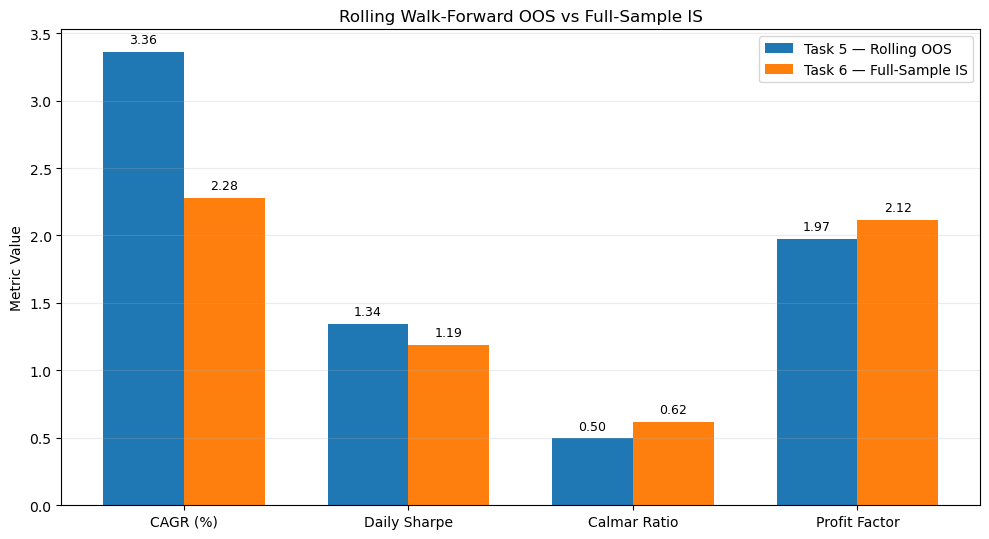

VISUAL COMPARISON VALUES


,Metric,Rolling OOS,Full-Sample IS
0,CAGR (%),3.3600,2.2800
1,Daily Sharpe,1.3450,1.1910
2,Calmar Ratio,0.4953,0.6205
3,Profit Factor,1.9740,2.1161


In [10]:
comparison_plot = pd.DataFrame(
    {
        "Metric": [
            "CAGR (%)",
            "Daily Sharpe",
            "Calmar Ratio",
            "Profit Factor"
        ],

        "Rolling OOS": [
            task5_portfolio["CAGR"] * 100,
            task5_portfolio["Daily Sharpe Ratio"],
            task5_portfolio["Calmar Ratio"],
            task5_trades["Profit Factor"]
        ],

        "Full-Sample IS": [
            task6_portfolio["CAGR"] * 100,
            task6_portfolio["Daily Sharpe Ratio"],
            task6_portfolio["Calmar Ratio"],
            task6_trades["Profit Factor"]
        ]
    }
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

x = np.arange(len(comparison_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))

bars_oos = ax.bar(
    x - width / 2,
    comparison_plot["Rolling OOS"],
    width,
    label="Task 5 — Rolling OOS"
)

bars_is = ax.bar(
    x + width / 2,
    comparison_plot["Full-Sample IS"],
    width,
    label="Task 6 — Full-Sample IS"
)

ax.set_xticks(x)
ax.set_xticklabels(comparison_plot["Metric"])

ax.set_ylabel("Metric Value")

ax.set_title(
    "Rolling Walk-Forward OOS vs Full-Sample IS"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)


# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bars in [bars_oos, bars_is]:

    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f"{height:.2f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Supporting values
# ------------------------------------------------------------

comparison_display = comparison_plot.copy()

comparison_display["CAGR (%)"] = np.nan  # placeholder not displayed

print(
    "VISUAL COMPARISON VALUES"
)

print(
    "=" * 75
)

display(
    comparison_plot.round(4)
)

## 6. Final Comparison and Conclusion

### 6.1 Final Comparison Summary

The table below consolidates the main portfolio-level and trade-level evidence
from the comparison between the Rolling Walk-Forward OOS procedure and the
Full-Sample IS benchmark.

The comparison should be interpreted as an assessment of historical
generalization rather than a direct horse race between the two procedures,
because their parameter-selection methods and evaluation periods differ.

In [11]:
final_comparison = pd.DataFrame(
    {
        "Metric": [
            "CAGR",
            "Maximum Drawdown (%)",
            "Daily Sharpe Ratio",
            "Calmar Ratio",
            "Win Rate",
            "Profit Factor",
            "Expectancy per Trade",
            "Winner / Loser Payoff Ratio"
        ],

        "Rolling OOS": [
            f"{task5_portfolio['CAGR']:.2%}",
            f"{task5_portfolio['Maximum Drawdown (%)']:.2%}",
            f"{task5_portfolio['Daily Sharpe Ratio']:.4f}",
            f"{task5_portfolio['Calmar Ratio']:.4f}",
            f"{task5_trades['Win Rate']:.2%}",
            f"{task5_trades['Profit Factor']:.4f}",
            f"${task5_trades['Expectancy per Trade']:,.2f}",
            f"{task5_trades['Winner / Loser Payoff Ratio']:.4f}"
        ],

        "Full-Sample IS": [
            f"{task6_portfolio['CAGR']:.2%}",
            f"{task6_portfolio['Maximum Drawdown (%)']:.2%}",
            f"{task6_portfolio['Daily Sharpe Ratio']:.4f}",
            f"{task6_portfolio['Calmar Ratio']:.4f}",
            f"{task6_trades['Win Rate']:.2%}",
            f"{task6_trades['Profit Factor']:.4f}",
            f"${task6_trades['Expectancy per Trade']:,.2f}",
            f"{task6_trades['Winner / Loser Payoff Ratio']:.4f}"
        ],

        "Interpretation": [
            "Higher under Rolling OOS",
            "Larger under Rolling OOS",
            "Higher under Rolling OOS",
            "Higher under Full-Sample IS",
            "Approximately unchanged",
            "Moderately lower under Rolling OOS",
            "Lower but remains positive",
            "Moderately lower but remains > 1"
        ]
    }
)

print(
    "TASK 7 — FINAL COMPARISON SUMMARY"
)

print(
    "=" * 90
)

display(
    final_comparison
)

TASK 7 — FINAL COMPARISON SUMMARY


,Metric,Rolling OOS,Full-Sample IS,Interpretation
0,CAGR,3.36%,2.28%,Higher under Rolling OOS
1,Maximum Drawdown (%),-6.79%,-3.68%,Larger under Rolling OOS
2,Daily Sharpe Ratio,1.3450,1.1910,Higher under Rolling OOS
3,Calmar Ratio,0.4953,0.6205,Higher under Full-Sample IS
4,Win Rate,43.65%,43.22%,Approximately unchanged
5,Profit Factor,1.9740,2.1161,Moderately lower under Rolling OOS
6,Expectancy per Trade,$117.86,$155.76,Lower but remains positive
7,Winner / Loser Payoff Ratio,2.5487,2.7802,Moderately lower but remains > 1


### 6.2 Final Conclusion

Task 7 compares the Rolling Walk-Forward OOS results from Task 5 with the
Full-Sample IS benchmark from Task 6 to assess whether the strategy's
historical performance remains economically meaningful outside the
full-sample optimization setting.

At the portfolio level, the Rolling OOS procedure produces a 3.36% CAGR and
a Daily Sharpe Ratio of 1.3450, both higher than the corresponding
Full-Sample IS values of 2.28% and 1.1910. This stronger return performance,
however, is accompanied by greater downside risk. The OOS maximum drawdown is
6.79%, compared with 3.68% for the Full-Sample IS benchmark, which results in
a lower OOS Calmar Ratio of 0.4953 versus 0.6205.

At the trade level, the strategy's characteristic asymmetric payoff structure
remains broadly present under rolling out-of-sample evaluation. The OOS win
rate of 43.65% is nearly unchanged from the Full-Sample IS win rate of 43.22%.
Profit Factor declines moderately from 2.1161 to 1.9740, while the
winner-to-loser payoff ratio remains strongly above 1 at 2.5487. Expectancy
per completed trade decreases from $155.76 to $117.86 but remains positive.
The reduction in per-trade edge is driven primarily by smaller average winning
trades rather than a deterioration in win frequency.

Taken together, the results do not show the severe deterioration that would
typically raise strong concerns about full-sample overfitting. Profitability,
positive risk-adjusted performance, and favorable payoff asymmetry remain
present after repeated parameter estimation followed by evaluation on unseen
quarters. The evidence therefore supports historical robustness of the
strategy under the walk-forward framework, while also showing that some
trade-level edge and drawdown efficiency weaken outside the Full-Sample IS
setting.

The comparison should nevertheless not be interpreted as proof that Rolling
OOS strictly outperforms Full-Sample IS, nor as proof that the strategy is free
from overfitting. Task 5 and Task 6 use different parameter-selection
mechanisms and different evaluation periods. The Full-Sample IS result should
therefore be treated as a hindsight-optimized in-sample benchmark, whereas the
Rolling OOS result provides the more relevant evidence on historical
generalization.

Neither result guarantees future trading performance.